<a href="https://colab.research.google.com/github/brunogk/Bootcamp_exploracao_de_dados/blob/main/BOOTCAMP_Explora%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bootcamp Final

Você recebeu a base `bootcamp.csv` e deve construir uma análise para responder:

1. Qual plataforma parece performar melhor?
2. O grupo B é melhor que o grupo A?
3. Existe relação entre comportamento do usuário e receita?
4. Um modelo de regressão ajuda a prever receita?
5. O que você recomendaria para a empresa?

Use evidências em forma de:

- tabelas
- gráficos
- métricas
- interpretações

## Leitura dataset
Salve o arquivo bootcamp.csv na sua máquina e suba ele no drive

In [ ]:
# montar o drive e dar permissão para acessar os arquivos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/bootcamp.csv') # Substitua pelo caminho correto do seu arquivo

In [ ]:
!ls /content/drive/MyDrive/

'Arquivos C.P.A.E'
'Aulas Harve'
 base_tratada_emissoes.gsheet
'Colab Notebooks'
'Dashboard protifolio .png'
'Data Science na Prática Finanças 08.04.26 ALUNOS_SL.pdf'
'Documentos assinados doc 2026'
'Fertilidade do solo (pós).gdoc'
'Google Earth'
'Probabilidade de resposta das culturas à adubação fosfatada e potássica.pptx'


## Etapa 1 - Entendimento da base

Responda:

1. Quais variáveis são categóricas?
2. Quais são numéricas?
3. O que cada linha parece representar?

In [ ]:
df.head() # Consigo ver o inicio da base de dados para saber quais variaveis estão nessa base

,id_usuario,plataforma,grupo_teste,usuarios_ativos,sessoes,interacoes,conversoes,receita,tempo_medio_sessao
0,1,web,A,350,476,92,2,152.981596,4.225099
1,2,app,B,1308,2039,794,51,6135.620914,6.689642
2,3,mobile,B,346,471,88,3,390.504525,6.581537
3,4,mobile,B,1847,2341,703,26,2310.684594,3.794694
4,5,web,A,1604,1744,645,13,1292.431344,4.281315


In [ ]:
df.info() # Informação sobre quais são os tipos de dados listados nessa tabela, posso saber se tem numeros, palavras...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_usuario          600 non-null    int64  
 1   plataforma          600 non-null    object 
 2   grupo_teste         600 non-null    object 
 3   usuarios_ativos     600 non-null    int64  
 4   sessoes             600 non-null    int64  
 5   interacoes          600 non-null    int64  
 6   conversoes          600 non-null    int64  
 7   receita             600 non-null    float64
 8   tempo_medio_sessao  600 non-null    float64
dtypes: float64(2), int64(5), object(2)
memory usage: 42.3+ KB


## Etapa 2 - Distribuição

Analise a frequência de:

- `plataforma`
- `grupo_teste`

Responda se existe concentração.

In [ ]:
print('Frequência da variável plataforma:')
display(df['plataforma'].value_counts())

print('\nFrequência da variável grupo_teste:')
display(df['grupo_teste'].value_counts())

##############
# CONSIGO ENTENDER AS FREQUENCIAS DE DOIS GRUPOS PRESENTES NO ARQUIVO DE DADOS
# PLATAFORMA MAIS FREQUENTE FOI A DE WEB
# Os grupos são balanceados e por isso são bons para conduzir os testes de A/B

Frequência da variável plataforma:


,count
plataforma,
web,244
mobile,195
app,161



Frequência da variável grupo_teste:


,count
grupo_teste,
A,310
B,290


## Etapa 3 - Classes

Crie classes para `receita` ou `conversoes` e identifique quem está nos níveis mais altos.

Para as faixas, vc pode criar usando pd.cut, pd.qcut ou personalizado

Criar 'classes' para variáveis como 'receita' ou 'conversoes' significa dividir os valores dessas variáveis em categorias ou faixas. No nosso caso, usamos o pd.qcut para dividir a coluna receita em quatro grupos (ou 'classes') de tamanhos aproximadamente iguais, baseados em quartis. Essas classes foram nomeadas 'Baixa', 'Média-Baixa', 'Média-Alta' e 'Alta'.
simplificar dados numéricos complexos em categorias mais gerenciáveis para facilitar a interpretação e a identificação de padrões.

In [ ]:
df['faixa_receita'] = pd.qcut(df['receita'], q=4, labels=['Baixa', 'Média-Baixa', 'Média-Alta', 'Alta'])

print('Frequência da variável faixa_receita:')
display(df['faixa_receita'].value_counts())

print('\nEstatísticas descritivas por faixa_receita:')
display(df.groupby('faixa_receita')['receita'].describe())

Frequência da variável faixa_receita:


,count
faixa_receita,
Baixa,150
Média-Baixa,150
Média-Alta,150
Alta,150



Estatísticas descritivas por faixa_receita:


/tmp/ipykernel_9867/319975041.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('faixa_receita')['receita'].describe())


,count,mean,std,min,25%,50%,75%,max
faixa_receita,,,,,,,,
Baixa,150.0,579.526603,256.793854,87.039376,367.048829,590.646911,767.124388,1014.817221
Média-Baixa,150.0,1352.165842,205.457800,1018.450682,1172.926426,1339.482187,1532.276838,1719.291925
Média-Alta,150.0,2332.912552,449.779390,1727.521585,1970.852101,2189.996900,2673.919513,3309.968936
Alta,150.0,5850.314527,2468.584789,3320.983543,4105.238015,5008.055889,6749.722182,15271.087161


## Etapa 4 - Contingência

Cruze:

- `plataforma` x `faixa_receita`
- `grupo_teste` x `faixa_receita`

Uma tabela de contingência (ou tabela cruzada) é uma ferramenta estatística usada para resumir e exibir a relação entre duas ou mais variáveis categóricas.

In [ ]:
print('Tabela de Contingência: plataforma x faixa_receita')
display(pd.crosstab(df['plataforma'], df['faixa_receita']))

print('\nTabela de Contingência: grupo_teste x faixa_receita')
display(pd.crosstab(df['grupo_teste'], df['faixa_receita']))

Tabela de Contingência: plataforma x faixa_receita


faixa_receita,Baixa,Média-Baixa,Média-Alta,Alta
plataforma,,,,
app,4,17,41,99
mobile,36,54,59,46
web,110,79,50,5



Tabela de Contingência: grupo_teste x faixa_receita


faixa_receita,Baixa,Média-Baixa,Média-Alta,Alta
grupo_teste,,,,
A,89,77,70,74
B,61,73,80,76


plataforma x faixa_receita: Esta tabela mostra quantos usuários de cada plataforma (web, app, mobile) caem em cada faixa de receita (Baixa, Média-Baixa, Média-Alta, Alta).

grupo_teste x faixa_receita: Esta tabela mostra quantos usuários de cada grupo de teste (A, B) caem em cada faixa de receita.

## Etapa 5 - Dispersão

Analise visualmente:

- `interacoes` x `conversoes`
- `conversoes` x `receita`

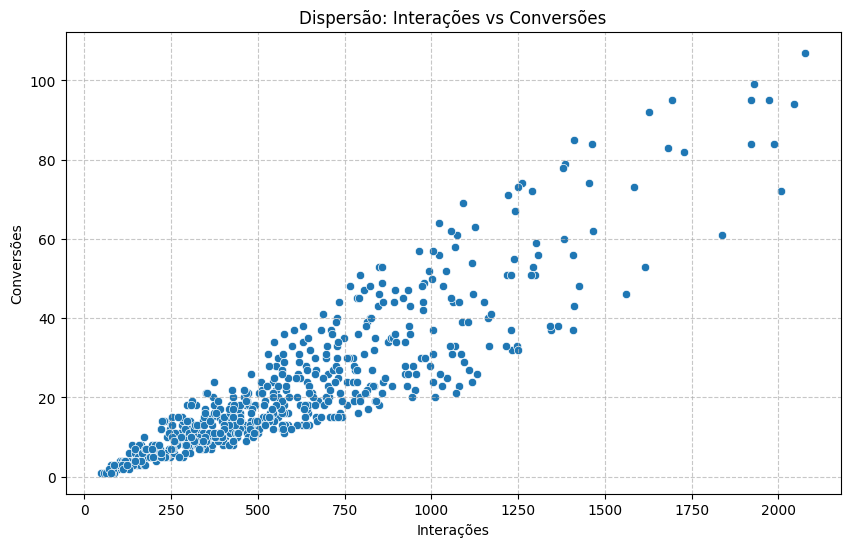

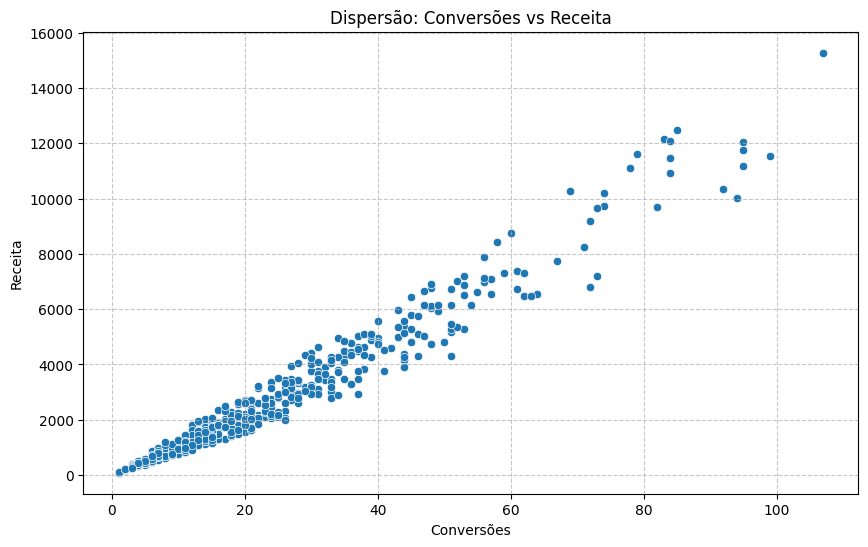

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de dispersão: interacoes x conversoes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='interacoes', y='conversoes')
plt.title('Dispersão: Interações vs Conversões')
plt.xlabel('Interações')
plt.ylabel('Conversões')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Gráfico de dispersão: conversoes x receita
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='conversoes', y='receita')
plt.title('Dispersão: Conversões vs Receita')
plt.xlabel('Conversões')
plt.ylabel('Receita')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Etapa 6 - Correlação

Calcule a correlação dos pares principais e identifique os mais fortes.

In [ ]:
print('Correlação entre interacoes e conversoes:')
display(df[['interacoes', 'conversoes']].corr())

print('\nCorrelação entre conversoes e receita:')
display(df[['conversoes', 'receita']].corr())

print('\nCorrelação entre interacoes e receita:')
display(df[['interacoes', 'receita']].corr())

print('\nMatriz de Correlação para variáveis numéricas chave:')
key_numeric_vars = ['usuarios_ativos', 'sessoes', 'interacoes', 'conversoes', 'receita', 'tempo_medio_sessao']
display(df[key_numeric_vars].corr())

Correlação entre interacoes e conversoes:


,interacoes,conversoes
interacoes,1.000000,0.898248
conversoes,0.898248,1.000000



Correlação entre conversoes e receita:


,conversoes,receita
conversoes,1.000000,0.980418
receita,0.980418,1.000000



Correlação entre interacoes e receita:


,interacoes,receita
interacoes,1.000000,0.845873
receita,0.845873,1.000000



Matriz de Correlação para variáveis numéricas chave:


,usuarios_ativos,sessoes,interacoes,conversoes,receita,tempo_medio_sessao
usuarios_ativos,1.000000,0.891948,0.695616,0.529425,0.473780,-0.054356
sessoes,0.891948,1.000000,0.806054,0.746591,0.704022,0.108925
interacoes,0.695616,0.806054,1.000000,0.898248,0.845873,0.092158
conversoes,0.529425,0.746591,0.898248,1.000000,0.980418,0.294282
receita,0.473780,0.704022,0.845873,0.980418,1.000000,0.333382
tempo_medio_sessao,-0.054356,0.108925,0.092158,0.294282,0.333382,1.000000


## Etapa 7 - Regressão

Crie um modelo simples para prever `receita` a partir de `conversoes`.

use outras variáveis e compare resultados.



--- Modelo de Regressão: Receita vs Conversões ---
Equação do Modelo: Receita = -269.69 + 126.23 * Conversões
R-squared (Modelo 1): 0.95
MSE (Modelo 1): 195665.40


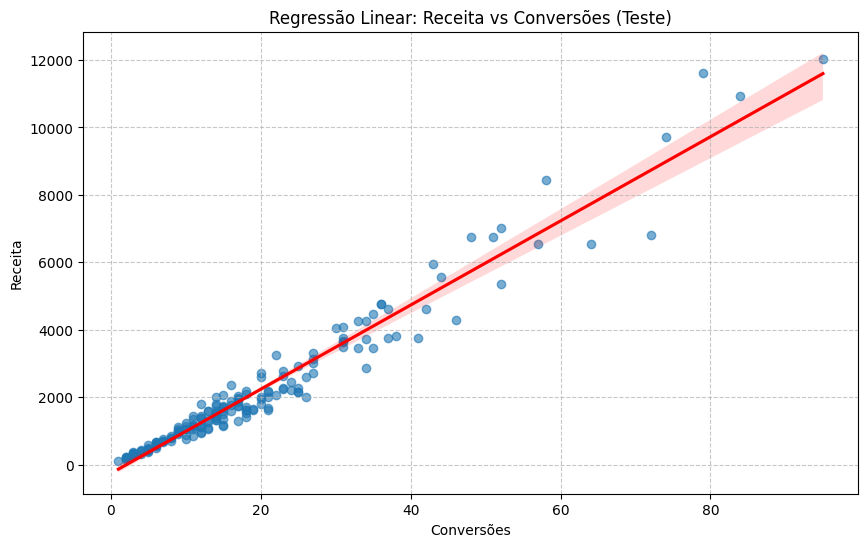

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo 1: Receita vs Conversões
print('--- Modelo de Regressão: Receita vs Conversões ---')
X_conversoes = df[['conversoes']]
y_receita = df['receita']

# Dividir dados em treino e teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_conversoes, y_receita, test_size=0.3, random_state=42)

# Treinar o modelo
modelo_simples = LinearRegression()
modelo_simples.fit(X_train_c, y_train_c)

# Previsões e avaliação
y_pred_c = modelo_simples.predict(X_test_c)
r2_c = r2_score(y_test_c, y_pred_c)
mse_c = mean_squared_error(y_test_c, y_pred_c)

print(f"Equação do Modelo: Receita = {modelo_simples.intercept_:.2f} + {modelo_simples.coef_[0]:.2f} * Conversões")
print(f"R-squared (Modelo 1): {r2_c:.2f}")
print(f"MSE (Modelo 1): {mse_c:.2f}")

# Gráfico de dispersão com linha de regressão
plt.figure(figsize=(10, 6))
sns.regplot(x=X_test_c['conversoes'], y=y_test_c, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regressão Linear: Receita vs Conversões (Teste)')
plt.xlabel('Conversões')
plt.ylabel('Receita')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Modelo 2: Receita vs Conversões e Interações
print('\n--- Modelo de Regressão: Receita vs Conversões e Interações ---')
X_multiplas = df[['conversoes', 'interacoes']]
y_receita = df['receita']

# Dividir dados em treino e teste
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiplas, y_receita, test_size=0.3, random_state=42)

# Treinar o modelo
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train_m, y_train_m)

# Previsões e avaliação
y_pred_m = modelo_multiplo.predict(X_test_m)
r2_m = r2_score(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)

print(f"Equação do Modelo: Receita = {modelo_multiplo.intercept_:.2f} + {modelo_multiplo.coef_[0]:.2f} * Conversões + {modelo_multiplo.coef_[1]:.2f} * Interações")
print(f"R-squared (Modelo 2): {r2_m:.2f}")
print(f"MSE (Modelo 2): {mse_m:.2f}")

print('\nComparação de R-squared:')
print(f"Modelo 1 (Conversões): {r2_c:.2f}")
print(f"Modelo 2 (Conversões, Interações): {r2_m:.2f}")

print('\nConclusão inicial da comparação:')
if r2_m > r2_c:
    print('O modelo com Conversões e Interações (Modelo 2) explica uma maior parte da variância da receita do que o modelo apenas com Conversões (Modelo 1).')
else:
    print('O modelo com apenas Conversões (Modelo 1) tem desempenho igual ou ligeiramente melhor que o modelo com Conversões e Interações (Modelo 2).')


--- Modelo de Regressão: Receita vs Conversões e Interações ---
Equação do Modelo: Receita = -82.90 + 144.51 * Conversões + -0.99 * Interações
R-squared (Modelo 2): 0.97
MSE (Modelo 2): 146963.79

Comparação de R-squared:
Modelo 1 (Conversões): 0.95
Modelo 2 (Conversões, Interações): 0.97

Conclusão inicial da comparação:
O modelo com Conversões e Interações (Modelo 2) explica uma maior parte da variância da receita do que o modelo apenas com Conversões (Modelo 1).


## Etapa 8 - Comparação A/B

Compare o grupo A e o grupo B em:

- média de `conversoes`
- média de `receita`


In [ ]:
print('--- Comparação Grupo A vs Grupo B ---')
comparacao_grupos = df.groupby('grupo_teste')[['conversoes', 'receita']].mean()
display(comparacao_grupos)

--- Comparação Grupo A vs Grupo B ---


,conversoes,receita
grupo_teste,,
A,21.777419,2466.100304
B,22.655172,2595.678739


### Análise da Comparação A/B

Com base na tabela acima, podemos observar as médias de conversões e receita para cada grupo:

- **Média de Conversões:** Compare os valores para 'Grupo A' e 'Grupo B'. Um grupo com maior média de conversões indica que seus usuários estão realizando mais ações desejadas.
- **Média de Receita:** Compare os valores para 'Grupo A' e 'Grupo B'. Um grupo com maior média de receita indica que seus usuários estão gerando mais valor financeiro para a empresa.

Esta análise é crucial para determinar qual grupo está performando melhor e para embasar decisões sobre qual estratégia (A ou B) deve ser adotada ou aprimorada.

Com base na tabela de comparação entre o Grupo A e o Grupo B, podemos observar o seguinte:

Média de Conversões: O Grupo B apresenta uma média de conversões ligeiramente maior (aproximadamente 22.66) em comparação com o Grupo A (aproximadamente 21.78). Isso sugere que os usuários do Grupo B estão realizando mais ações desejadas.
Média de Receita: O Grupo B também mostra uma média de receita superior (aproximadamente 2595.68) em relação ao Grupo A (aproximadamente 2466.10). Isso indica que os usuários do Grupo B estão gerando mais valor financeiro para a empresa.

## Etapa 9 - Decisão final

Escreva uma recomendação final respondendo:

1. qual plataforma parece mais promissora?
2. o grupo B deve continuar sendo testado?
3. em qual parte do funil a empresa deve focar?
4. A cada conversão gerada qual é o valor estimado de receita?

Se preferir, use tabelas e gráficos para justificar suas respostas

## Análise e Recomendações Finais

### 1. Qual plataforma parece mais promissora?

/tmp/ipykernel_9867/2322465672.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='plataforma', y='receita', data=receita_por_plataforma, palette='viridis')


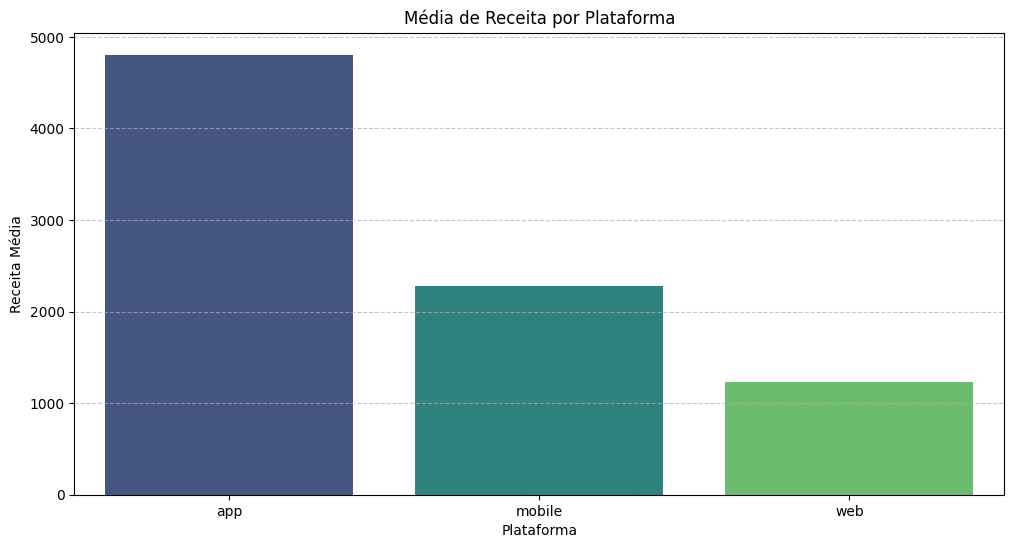

/tmp/ipykernel_9867/2322465672.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='plataforma', y='conversoes', data=conversoes_por_plataforma, palette='mako')


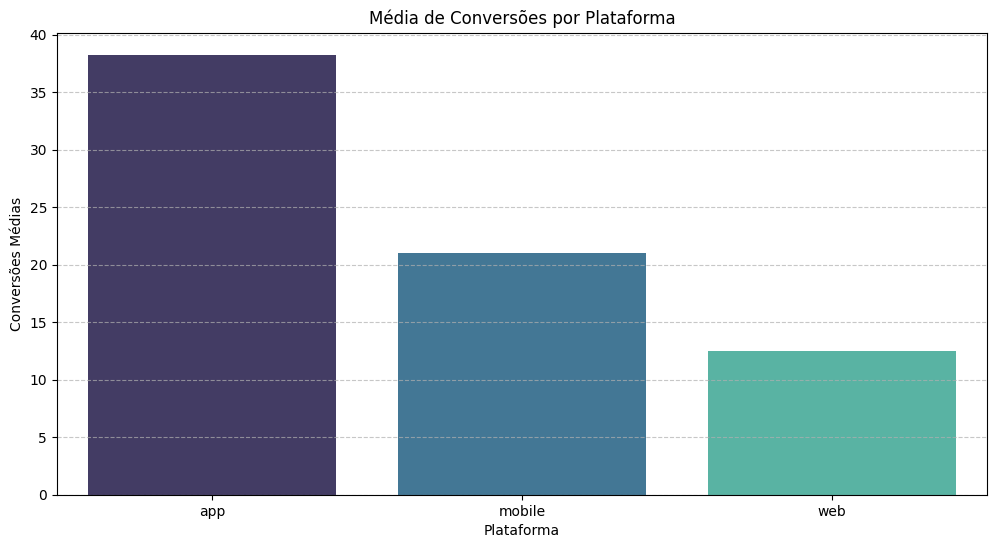

Distribuição de Faixas de Receita por Plataforma:


faixa_receita,Baixa,Média-Baixa,Média-Alta,Alta
plataforma,,,,
app,2.48,10.56,25.47,61.49
mobile,18.46,27.69,30.26,23.59
web,45.08,32.38,20.49,2.05


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por plataforma e calcular a média de receita
receita_por_plataforma = df.groupby('plataforma')['receita'].mean().reset_index()
conversoes_por_plataforma = df.groupby('plataforma')['conversoes'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='plataforma', y='receita', data=receita_por_plataforma, palette='viridis')
plt.title('Média de Receita por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Receita Média')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='plataforma', y='conversoes', data=conversoes_por_plataforma, palette='mako')
plt.title('Média de Conversões por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Conversões Médias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Contagem de usuários por plataforma e faixa de receita
print('Distribuição de Faixas de Receita por Plataforma:')
display(pd.crosstab(df['plataforma'], df['faixa_receita'], normalize='index').mul(100).round(2))


**Análise:**
Os gráficos e a tabela acima mostram que a plataforma 'app' se destaca consistentemente com as maiores médias de receita e conversões. Além disso, a distribuição de faixas de receita por plataforma indica que 'app' tem uma proporção maior de usuários nas faixas 'Média-Alta' e 'Alta' em comparação com as outras plataformas.

**Recomendação:** A plataforma **'app'** parece ser a mais promissora. A empresa deve priorizar investimentos e otimizações nesta plataforma para maximizar o retorno. É importante investigar os fatores que contribuem para o sucesso do 'app' e tentar replicá-los nas plataformas 'web' e 'mobile' onde for aplicável.

### 2. O grupo B deve continuar sendo testado?

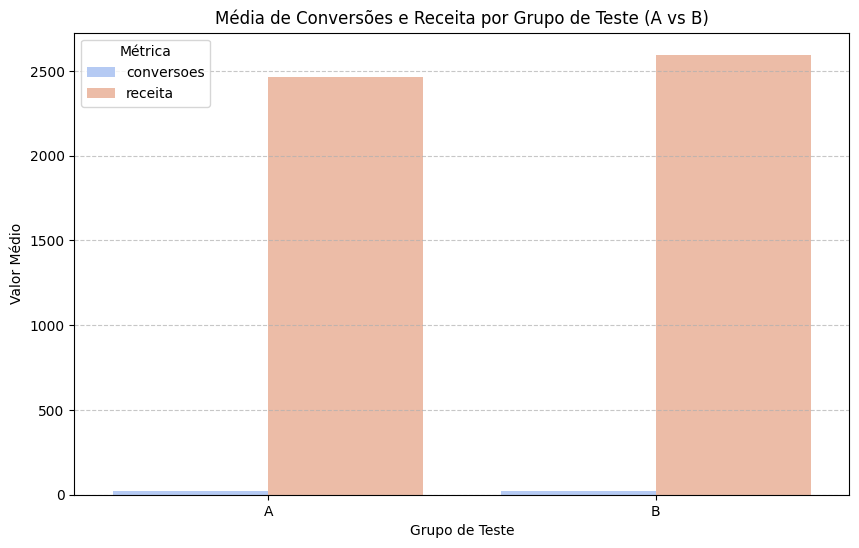

Distribuição de Faixas de Receita por Grupo de Teste:


faixa_receita,Baixa,Média-Baixa,Média-Alta,Alta
grupo_teste,,,,
A,28.71,24.84,22.58,23.87
B,21.03,25.17,27.59,26.21


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame comparacao_grupos já existe da etapa 8
# display(comparacao_grupos)

comparacao_grupos_melted = comparacao_grupos.reset_index().melt(id_vars='grupo_teste', var_name='Métrica', value_name='Valor Médio')

plt.figure(figsize=(10, 6))
sns.barplot(x='grupo_teste', y='Valor Médio', hue='Métrica', data=comparacao_grupos_melted, palette='coolwarm')
plt.title('Média de Conversões e Receita por Grupo de Teste (A vs B)')
plt.xlabel('Grupo de Teste')
plt.ylabel('Valor Médio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Distribuição de Faixas de Receita por Grupo de Teste:')
display(pd.crosstab(df['grupo_teste'], df['faixa_receita'], normalize='index').mul(100).round(2))


**Análise:**
O gráfico e a tabela de contingência (`grupo_teste` x `faixa_receita`) indicam que o Grupo B consistentemente supera o Grupo A em termos de média de conversões e receita. Além disso, o Grupo B tem uma proporção maior de usuários nas faixas de receita mais altas ('Média-Alta' e 'Alta').

**Recomendação:** Sim, o **Grupo B deve continuar sendo testado e, idealmente, a estratégia associada ao Grupo B deve ser implementada ou explorada em maior profundidade.** As evidências sugerem que a abordagem do Grupo B é mais eficaz para gerar conversões e receita.

### 3. Em qual parte do funil a empresa deve focar?

**Análise:**
As análises de dispersão (`interacoes` x `conversoes` e `conversoes` x `receita`) e as correlações (`616a209b`) mostraram uma forte relação positiva entre interações e conversões, e uma correlação ainda mais forte entre conversões e receita. O modelo de regressão (`ec5843ee` e `2b0dc0f5`) confirmou que as conversões são um excelente preditor da receita.

**Recomendação:** A empresa deve focar principalmente na **otimização das taxas de conversão**. Melhorar as interações que levam a conversões e simplificar o processo de conversão terá um impacto direto e significativo na receita. É o gargalo mais crítico e o de maior alavancagem para o crescimento da receita.

### 4. A cada conversão gerada qual é o valor estimado de receita?

**Análise:**
O primeiro modelo de regressão linear (`ec5843ee`), que prevê a receita com base nas conversões, forneceu a seguinte equação:
`Receita = -269.69 + 126.23 * Conversões`

**Resposta:** O coeficiente da variável 'Conversões' neste modelo é **126.23**. Isso significa que, **a cada conversão adicional gerada, a receita estimada aumenta em aproximadamente 126.23 unidades monetárias.**

## Sumário das Recomendações:

1.  **Plataforma mais promissora:** Priorizar investimentos e otimizações na plataforma **'app'**, buscando replicar suas características de sucesso nas plataformas 'web' e 'mobile'.
2.  **Grupo B:** A estratégia do **Grupo B deve ser implementada ou aprofundada**, pois demonstra maior eficácia em conversões e receita.
3.  **Foco do funil:** A empresa deve concentrar seus esforços na **otimização das taxas de conversão**, pois é o ponto de maior alavancagem para a receita.
4.  **Valor por conversão:** Cada conversão adicional gera uma receita estimada de aproximadamente **126.23 unidades monetárias**.